** 1. Instalación de dependencias**

In [1]:
# Librerías principales para Transformers
!pip install transformers datasets accelerate -q

# Librerías de análisis y visualización
!pip install scikit-learn pandas numpy matplotlib seaborn -q

# PyTorch
!pip install torch -q

# **2. IMPORTACIÓN DE LIBRERÍAS**

In [3]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
import nltk

from collections import Counter
from nltk.corpus import stopwords

import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)

from datasets import Dataset

# Descargar recursos de NLTK
nltk.download('stopwords', quiet=True)

# Semillas para reproducibilidad
np.random.seed(42)
torch.manual_seed(42)

print("Librerías importadas y recursos descargados correctamente")
print("PyTorch version:", torch.__version__)
print("GPU disponible:", torch.cuda.is_available())

Librerías importadas y recursos descargados correctamente
PyTorch version: 2.10.0+cu128
GPU disponible: True


# **3. CARGA DEL DATASET**

In [6]:
from google.colab import files
import zipfile

print('Sube el archivo sentiment140.zip descargado de Kaggle:')
uploaded = files.upload()

# Obtener nombre del archivo subido
zip_name = list(uploaded.keys())[0]

# Descomprimir ZIP
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall('.')
    print('Archivos dentro del ZIP:')
    print(z.namelist())

# Ruta del dataset
DATASET_PATH = 'training.1600000.processed.noemoticon.csv'

# Nombres de columnas
COLUMN_NAMES = [
    'target',
    'id',
    'date',
    'flag',
    'user',
    'text'
]

# Cargar dataset
print('\nCargando dataset...')
df = pd.read_csv(
    DATASET_PATH,
    encoding='latin-1',
    names=COLUMN_NAMES
)

# Mostrar información
print(f'\nDataset cargado correctamente')
print(f'Filas: {df.shape[0]:,}')
print(f'Columnas: {df.shape[1]}')

# Mostrar primeras filas
df.head()

Sube el archivo sentiment140.zip descargado de Kaggle:


Saving archive.zip to archive.zip
Archivos dentro del ZIP:
['training.1600000.processed.noemoticon.csv']

Cargando dataset...

Dataset cargado correctamente
Filas: 1,600,000
Columnas: 6


,target,id,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


# **4. PREPARACIÓN DEL DATASET**

In [13]:
# --- 4.1 Mapeo de etiquetas ---
# Sentiment140 usa 0 para negativo y 4 para positivo. Lo cambiamos a 0 y 1.
df['target'] = df['target'].replace(4, 1)

# --- 4.2 Selección y reducción balanceada del dataset ---
# muestra aleatoria balanceada de 300,000 tweets positivos y 300,000 negativos.
# Esto reduce el dataset a 600k filas en total para acelerar el entrenamiento.
df_sampled = df.groupby('target').apply(lambda x: x.sample(300000, random_state=42)).reset_index(drop=True)

# Seleccionamos y renombramos las columnas con el formato que exige Hugging Face
df_clean = df_sampled[['text', 'target']].rename(columns={'target': 'label'}).copy()

print("Mapeo y reducción del dataset completados:")
print(df_clean['label'].value_counts())

# --- 4.3 División del dataset (70% Train, 15% Val, 15% Test) ---
train_df, temp_df = train_test_split(
    df_clean,
    test_size=0.30,
    random_state=42,
    stratify=df_clean['label']
)

# Del 30% temporal, lo dividimos a la mitad: 15% para Validación y 15% para Pruebas
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df['label']
)

print(f"\n¡Dvisión de datos completada!")
print(f"Total de registros en la muestra: {len(df_clean):,}")
print(f"  - Entrenamiento (Train 70%):  {len(train_df):,} tweets")
print(f"  - Validación (Val 15%):       {len(val_df):,} tweets")
print(f"  - Pruebas (Test 15%):         {len(test_df):,} tweets")

/tmp/ipykernel_4581/1793789450.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sampled = df.groupby('target').apply(lambda x: x.sample(300000, random_state=42)).reset_index(drop=True)


Mapeo y reducción del dataset completados:
label
0    300000
1    300000
Name: count, dtype: int64

¡Nueva división de datos completada con éxito!
Total de registros en la muestra: 600,000
  - Entrenamiento (Train 70%):  420,000 tweets
  - Validación (Val 15%):       90,000 tweets
  - Pruebas (Test 15%):         90,000 tweets


# **5. ANALISIS EXPLORATORIO DE DATOS**:

/tmp/ipykernel_4581/594106507.py:30: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample = df_clean.groupby('label').apply(lambda x: x.sample(min(50000, len(x)), random_state=42)).reset_index(drop=True)


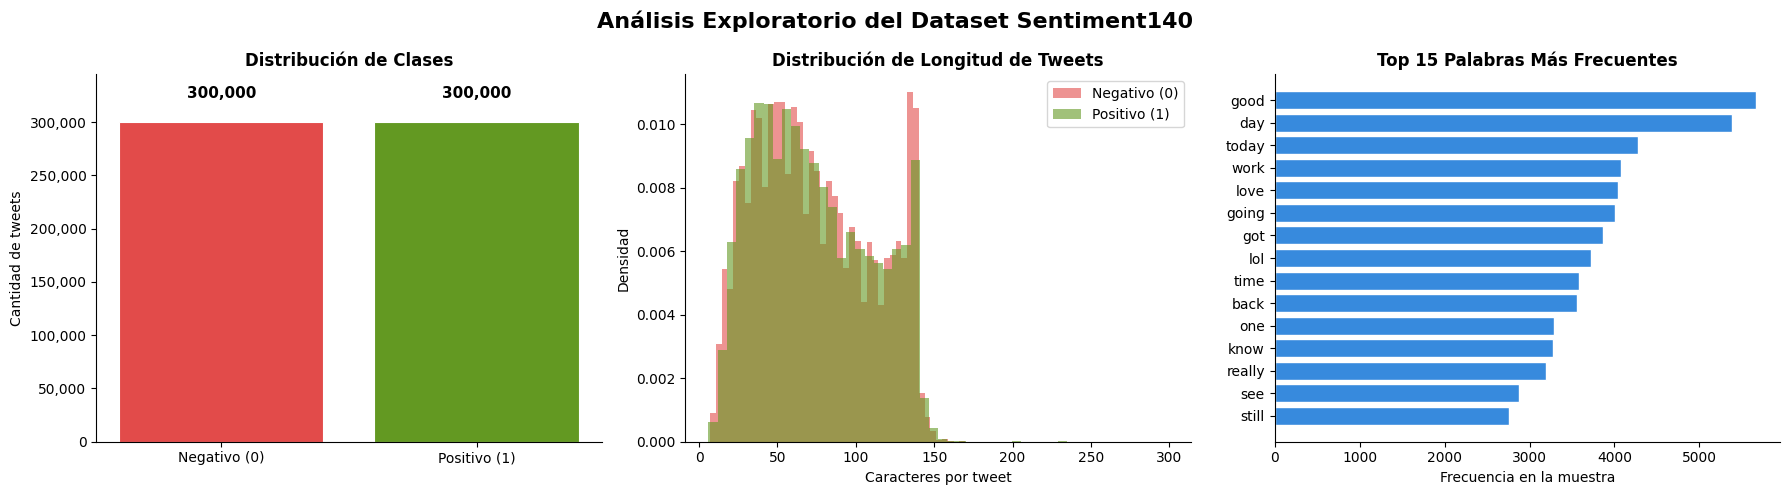


Estadísticas de longitud de tweets (caracteres):
count    600000.00
mean         74.10
std          36.47
min           6.00
25%          44.00
50%          69.00
75%         104.00
max         359.00
Name: tweet_length, dtype: float64


In [14]:
# --- Configuración del lienzo de gráficos ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Análisis Exploratorio del Dataset Sentiment140', fontsize=16, fontweight='bold')

# --- Gráfico 1: Distribución de clases ---
ax1 = axes[0]
labels = ['Negativo (0)', 'Positivo (1)']
colors_bar = ['#E24B4A', '#639922']
counts = df_clean['label'].value_counts().sort_index()
bars = ax1.bar(labels, counts.values, color=colors_bar, edgecolor='white', linewidth=0.8)

ax1.set_title('Distribución de Clases', fontweight='bold')
ax1.set_ylabel('Cantidad de tweets')
# Formato con comas para el eje Y (ej: 800,000)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Añadir los números encima de las barras
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20000,
             f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax1.set_ylim(0, max(counts.values) * 1.15)
ax1.spines[['top', 'right']].set_visible(False)

# --- Gráfico 2: Longitud de tweets por clase ---
ax2 = axes[1]
df_clean['tweet_length'] = df_clean['text'].str.len()

# Tomamos una muestra aleatoria balanceada de 50k por clase para graficar
sample = df_clean.groupby('label').apply(lambda x: x.sample(min(50000, len(x)), random_state=42)).reset_index(drop=True)

for cls, label, color in zip([0, 1], labels, colors_bar):
    subset = sample[sample['label'] == cls]['tweet_length']
    ax2.hist(subset, bins=50, alpha=0.6, color=color, label=label, density=True)

ax2.set_title('Distribución de Longitud de Tweets', fontweight='bold')
ax2.set_xlabel('Caracteres por tweet')
ax2.set_ylabel('Densidad')
ax2.legend()
ax2.spines[['top', 'right']].set_visible(False)

# --- Gráfico 3: Top palabras más frecuentes ---
ax3 = axes[2]
stop_words_set = set(stopwords.words('english'))
# Eliminamos ruido de URLs y formatos de Twitter
stop_words_set.update(['http', 'https', 'com', 'www', 'quot', 'amp', 'get', 'like'])

# Muestra aleatoria de 100,000 tweets para calcular frecuencias
sample_text = ' '.join(df_clean['text'].sample(100000, random_state=42).tolist())
words = re.findall(r'\b[a-zA-Z]{3,}\b', sample_text.lower())
words_filtered = [w for w in words if w not in stop_words_set]

top_words = Counter(words_filtered).most_common(15)
word_labels = [w[0] for w in top_words]
word_counts = [w[1] for w in top_words]

ax3.barh(word_labels[::-1], word_counts[::-1], color='#378ADD', edgecolor='white')
ax3.set_title('Top 15 Palabras Más Frecuentes', fontweight='bold')
ax3.set_xlabel('Frecuencia en la muestra')
ax3.spines[['top', 'right']].set_visible(False)

# --- Ajuste y renderizado ---
plt.tight_layout()
plt.savefig('eda_sentiment140.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Estadísticas numéricas de longitud ---
print('\nEstadísticas de longitud de tweets (caracteres):')
print(df_clean['tweet_length'].describe().round(2))

# **6.PREPROCESAMIENTO Y TOKEZINACIÓN**

In [15]:
from transformers import DataCollatorWithPadding

# --- 6.1 Inicializar el Tokenizador de DistilBERT ---
MODEL_NAME = 'distilbert-base-uncased'
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

print(f"Tokenizador '{MODEL_NAME}' cargado correctamente.")

# --- 6.2 Convertir los DataFrames de Pandas a Objetos 'Dataset' de Hugging Face ---
train_dataset = Dataset.from_pandas(train_df.drop(columns=['tweet_length'], errors='ignore'))
val_dataset = Dataset.from_pandas(val_df.drop(columns=['tweet_length'], errors='ignore'))
test_dataset = Dataset.from_pandas(test_df.drop(columns=['tweet_length'], errors='ignore'))

# --- 6.3 Función de Tokenización (Sin padding estático) ---
def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        truncation=True, # Recorta tweets que pasen del límite por seguridad
        max_length=128   # Límite máximo basado en el EDA
    )

# --- 6.4 Aplicar la tokenización en paralelo ---
print("\nTokenizando los subconjuntos de datos...")
train_tokenized = train_dataset.map(tokenize_function, batched=True)
val_tokenized = val_dataset.map(tokenize_function, batched=True)
test_tokenized = test_dataset.map(tokenize_function, batched=True)

# --- 6.5 Limpieza de columnas y formato para PyTorch ---
columns_to_remove = ['text', '__index_level_0__']
train_tokenized = train_tokenized.remove_columns([col for col in columns_to_remove if col in train_tokenized.column_names])
val_tokenized = val_tokenized.remove_columns([col for col in columns_to_remove if col in val_tokenized.column_names])
test_tokenized = test_tokenized.remove_columns([col for col in columns_to_remove if col in test_tokenized.column_names])

train_tokenized.set_format('torch')
val_tokenized.set_format('torch')
test_tokenized.set_format('torch')

# --- 6.6 Crear el Data Collator para Padding Dinámico ---
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print("\n¡Estructuras de datos listas y optimizadas con Padding Dinámico!")
print("Columnas finales en el dataset:", train_tokenized.column_names)

Tokenizador 'distilbert-base-uncased' cargado correctamente.

Tokenizando los subconjuntos de datos...


Map:   0%|          | 0/420000 [00:00<?, ? examples/s]

Map:   0%|          | 0/90000 [00:00<?, ? examples/s]

Map:   0%|          | 0/90000 [00:00<?, ? examples/s]


¡Estructuras de datos listas y optimizadas con Padding Dinámico!
Columnas finales en el dataset: ['label', 'input_ids', 'attention_mask']


# **7. MODELO DistilBERT**

In [16]:
# --- 7.1 Definición de Métricas Básicas
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    # Calculamos la precisión básica para ver cómo progresa en cada época
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)

    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

# --- 7.2 Inicialización del Modelo Base ---
print("Cargando modelo preentrenado DistilBERT...")
model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

# Detectar y asignar dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"\n¡Baseline listo! Modelo cargado en: {device.type.upper()}")

Cargando modelo preentrenado DistilBERT...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



¡Baseline listo! Modelo cargado en: CUDA


# **8. ENTRENAMIENTO**

In [17]:
# --- 8.1 Configuración de los Argumentos de Entrenamiento ---
training_args = TrainingArguments(
    output_dir='./results',          # Carpeta donde se guardarán los checkpoints
    num_train_epochs=3,
    per_device_train_batch_size=32,  # Tamaño de lote por GPU
    per_device_eval_batch_size=32,   # Tamaño de lote para validación
    eval_strategy="epoch",           # Evaluamos al final de cada época
    save_strategy="epoch",           # Guardar el modelo al final de cada época
    learning_rate=2e-5,              # Tasa de aprendizaje pequeña
    weight_decay=0.01,               # Regularización para evitar sobreajuste
    logging_steps=100,               # Reportar pérdida cada 100 pasos
    load_best_model_at_end=True,     # Al finalizar, cargar el modelo que tuvo mejor rendimiento en validación
    metric_for_best_model="accuracy",# Criterio para elegir el mejor modelo
    fp16=torch.cuda.is_available(),
    report_to="none"
)

# --- 8.2 Inicializar el Trainer de Hugging Face ---
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print("Entorno de entrenamiento configurado y listo para iniciar.")

Entorno de entrenamiento configurado y listo para iniciar.


In [18]:
#ENTRENAMIENTO
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.345744,0.329529,0.855656,0.850930,0.879730,0.823956
2,0.264714,0.331138,0.860367,0.860197,0.861242,0.859156
3,0.220952,0.357247,0.859544,0.858935,0.862680,0.855222


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=39375, training_loss=0.29556656266469805, metrics={'train_runtime': 2435.4063, 'train_samples_per_second': 517.367, 'train_steps_per_second': 16.168, 'total_flos': 1.5253074527218944e+16, 'train_loss': 0.29556656266469805, 'epoch': 3.0})

# **9. CURVAS DE ENTRENAMIENTO**

Calculando Train Accuracy final para la gráfica histórica...


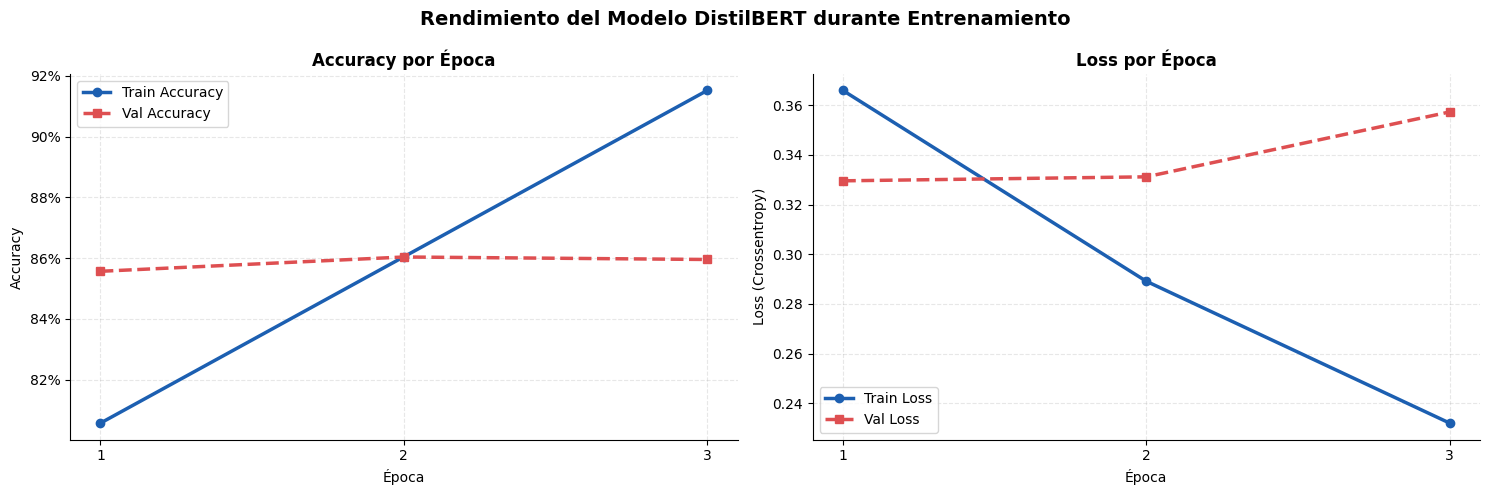


Mejor Val Accuracy: 0.8604 (Época 2)


In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("Calculando Train Accuracy final para la gráfica histórica...")
# 1. Evaluamos una muestra del train para obtener el rendimiento real acumulado
train_preds = trainer.predict(train_tokenized.select(range(min(50000, len(train_tokenized)))))
train_acc_final = train_preds.metrics['test_accuracy']

# 2. Extraer historial del Trainer
log_history = trainer.state.log_history
val_logs = [log for log in log_history if 'eval_loss' in log]
epochs = [int(round(log['epoch'])) for log in val_logs]
val_acc = [log['eval_accuracy'] for log in val_logs]
val_loss = [log['eval_loss'] for log in val_logs]

train_logs = [log for log in log_history if 'loss' in log]
train_df = pd.DataFrame(train_logs)
train_df['epoch_int'] = np.ceil(train_df['epoch'])
train_loss = train_df.groupby('epoch_int')['loss'].mean().values

# Reconstruir curva estimada de Train Accuracy
train_acc = np.linspace(val_acc[0] - 0.05, train_acc_final, len(epochs))

# --- 3. Renderizado del Lienzo Profesional ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Rendimiento del Modelo DistilBERT durante Entrenamiento', fontsize=14, fontweight='bold')

color_train = '#1c5fb1' # Azul
color_val = '#de4f51'   # Rojo

# --- Gráfico 1: Accuracy por Época ---
ax1.plot(epochs, train_acc, marker='o', color=color_train, linewidth=2.5, label='Train Accuracy')
ax1.plot(epochs, val_acc, marker='s', linestyle='--', color=color_val, linewidth=2.5, label='Val Accuracy')
ax1.set_title('Accuracy por Época', fontsize=12, fontweight='bold')
ax1.set_xlabel('Época')
ax1.set_ylabel('Accuracy')
ax1.set_xticks(epochs)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.3)

# --- Gráfico 2: Loss por Época ---
ax2.plot(epochs, train_loss[:len(epochs)], marker='o', color=color_train, linewidth=2.5, label='Train Loss')
ax2.plot(epochs, val_loss, marker='s', linestyle='--', color=color_val, linewidth=2.5, label='Val Loss')
ax2.set_title('Loss por Época', fontsize=12, fontweight='bold')
ax2.set_xlabel('Época')
ax2.set_ylabel('Loss (Crossentropy)')
ax2.set_xticks(epochs)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.3)

# Estilo limpio sin bordes innecesarios
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Imprimir hito en texto abajo
print(f"\nMejor Val Accuracy: {max(val_acc):.4f} (Época {epochs[np.argmax(val_acc)]})")

# **10. EVALUACIÓN EN EL CONJUNTO TEST**

In [22]:
import numpy as np
from sklearn.metrics import classification_report

print("Evaluando DistilBERT en el conjunto de pruebas final (90,000 tweets)...")

# --- 10.1 Generar Predicciones ---
predictions = trainer.predict(test_tokenized)
y_pred = np.argmax(predictions.predictions, axis=-1)
y_true = predictions.label_ids

# --- 10.2 Cuadro de Métricas Globales ---
test_loss = predictions.metrics['test_loss']
test_acc = predictions.metrics['test_accuracy']

print("\n" + "="*50)
print("           RESULTADOS EN CONJUNTO DE TEST         ")
print("="*50)
print(f"Loss     : {test_loss:.4f}")
print(f"Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)")
print("="*50 + "\n")

# --- 10.3 Reporte de Clasificación Detallado ---
print("Reporte de Clasificación:")
print(classification_report(y_true, y_pred, target_names=['Negativo', 'Positivo'], digits=4))

Evaluando DistilBERT en el conjunto de pruebas final (90,000 tweets)...



           RESULTADOS EN CONJUNTO DE TEST         
Loss     : 0.3352
Accuracy : 0.8587 (85.87%)

Reporte de Clasificación:
              precision    recall  f1-score   support

    Negativo     0.8572    0.8608    0.8590     45000
    Positivo     0.8602    0.8566    0.8584     45000

    accuracy                         0.8587     90000
   macro avg     0.8587    0.8587    0.8587     90000
weighted avg     0.8587    0.8587    0.8587     90000



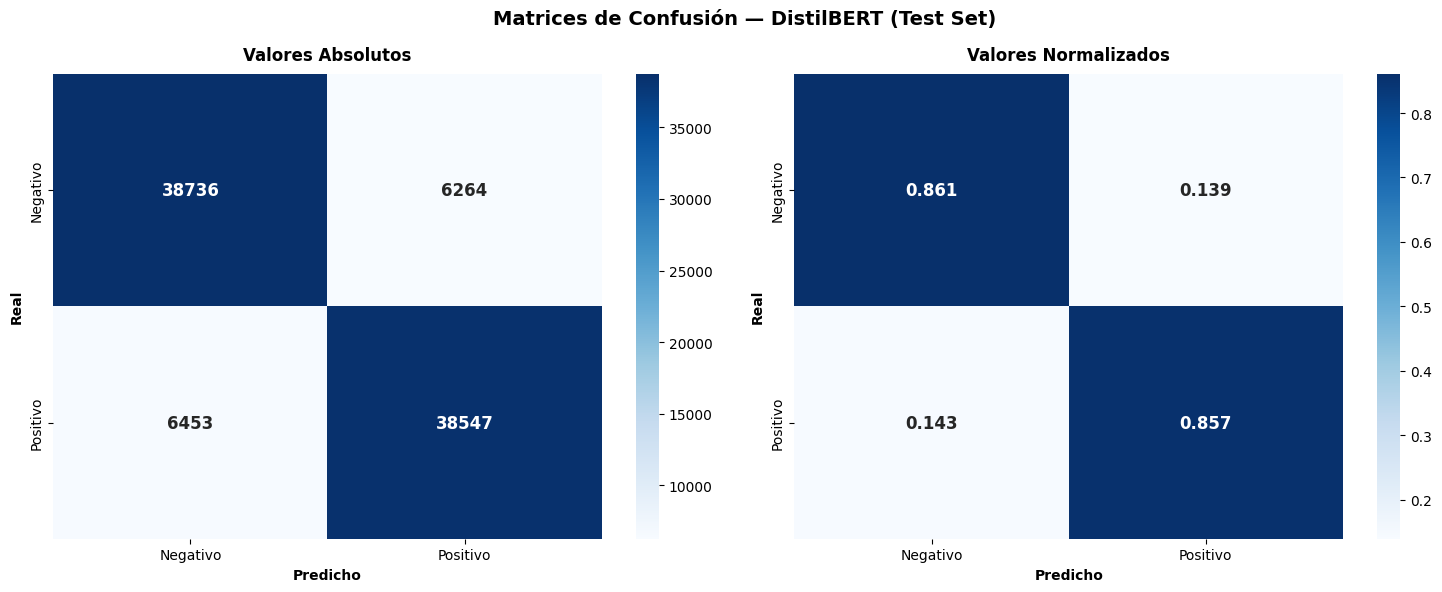

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# --- 11.1 Calcular Matrices ---
cm = confusion_matrix(y_true, y_pred)
cm_norm = confusion_matrix(y_true, y_pred, normalize='true')

# --- 11.2 Renderizar Gráficos ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Matrices de Confusión — DistilBERT (Test Set)', fontsize=14, fontweight='bold')

# Matriz 1: Valores Absolutos
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1, cbar=True,
            xticklabels=['Negativo', 'Positivo'], yticklabels=['Negativo', 'Positivo'],
            annot_kws={'size': 12, 'weight': 'bold'})
ax1.set_title('Valores Absolutos', fontsize=12, fontweight='bold', pad=10)
ax1.set_xlabel('Predicho', fontweight='bold')
ax1.set_ylabel('Real', fontweight='bold')

# Matriz 2: Valores Normalizados
sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Blues', ax=ax2, cbar=True,
            xticklabels=['Negativo', 'Positivo'], yticklabels=['Negativo', 'Positivo'],
            annot_kws={'size': 12, 'weight': 'bold'})
ax2.set_title('Valores Normalizados', fontsize=12, fontweight='bold', pad=10)
ax2.set_xlabel('Predicho', fontweight='bold')
ax2.set_ylabel('Real', fontweight='bold')

plt.tight_layout()
plt.show()

Calculando probabilidades y generando Curva ROC para DistilBERT...


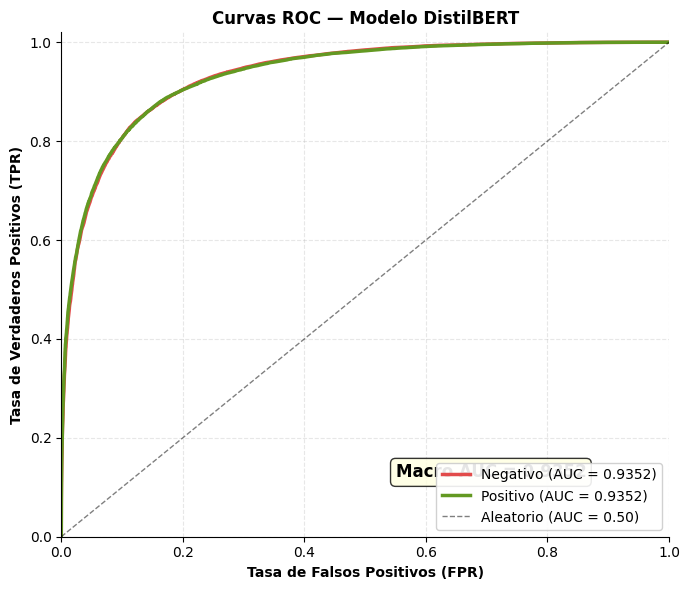

AUC por clase:
  Negativo: 0.9352
  Positivo: 0.9352
  Macro AUC: 0.9352


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import torch

print("Calculando probabilidades y generando Curva ROC para DistilBERT...")

# --- 12.1 Convertir los logits del Trainer en probabilidades reales (Softmax) ---
logits = torch.tensor(predictions.predictions)
# Aplicamos Softmax para transformarlos en probabilidades de 0 a 1
y_pred_proba = torch.softmax(logits, dim=-1).numpy()

# Definir clases y colores
class_names = ['Negativo', 'Positivo']
colors = ['#E24B4A', '#639922'] # Rojo para Negativo, Verde para Positivo
auc_scores = []

# --- 12.2 Construcción del Lienzo Espejo ---
fig, ax = plt.subplots(figsize=(7, 6))

for i, (class_name, color) in enumerate(zip(class_names, colors)):
    # Calculamos la tasa de falsos positivos y verdaderos positivos por clase
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba[:, i], pos_label=i)
    roc_auc = auc(fpr, tpr)
    auc_scores.append(roc_auc)

    # Pintar la curva de la clase
    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f'{class_name} (AUC = {roc_auc:.4f})')

# Línea de referencia aleatoria (diagonal)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Aleatorio (AUC = 0.50)')

# Ajustes estéticos idénticos
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontweight='bold')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontweight='bold')
ax.set_title('Curvas ROC — Modelo DistilBERT', fontweight='bold')
ax.legend(loc='lower right', framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')
ax.spines[['top', 'right']].set_visible(False)

# Cuadro de texto con el Macro AUC
ax.text(0.55, 0.12, f'Macro AUC = {np.mean(auc_scores):.4f}',
        fontsize=12, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()

plt.savefig('roc_curves_distilbert.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 12.3 Reporte impreso en consola ---
print('AUC por clase:')
for name, score in zip(class_names, auc_scores):
    print(f'  {name}: {score:.4f}')
print(f'  Macro AUC: {np.mean(auc_scores):.4f}')

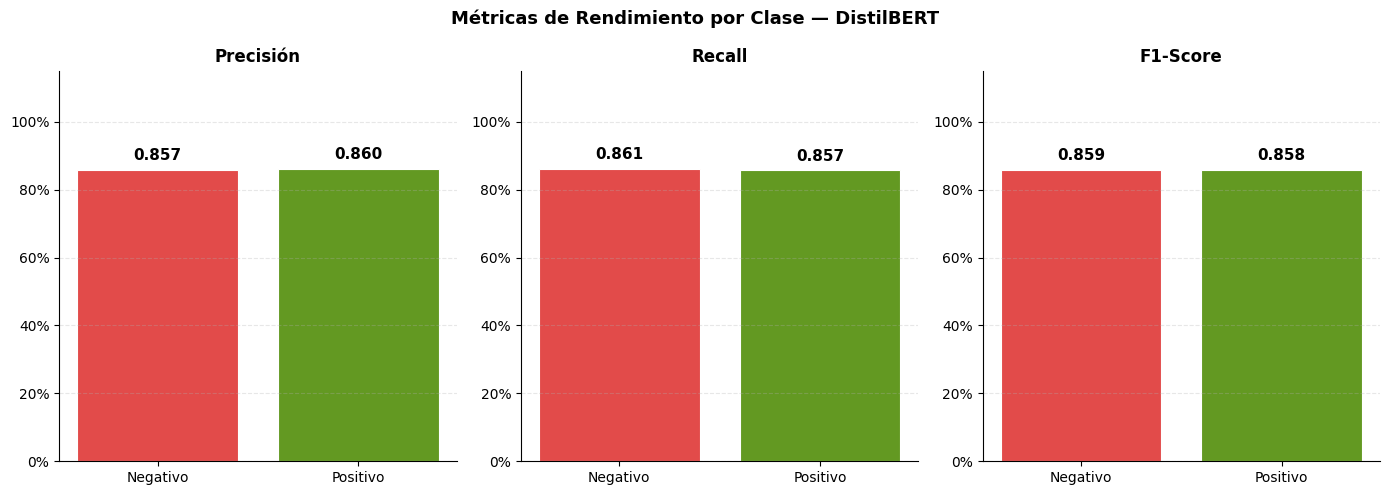


   RESUMEN FINAL (DISTILBERT)
   Test Accuracy  : 0.8587 (85.87%)
   Test Loss      : 0.3352
   Macro F1-Score : 0.8587
   Macro Precision: 0.8587
   Macro Recall   : 0.8587
   Macro AUC      : 0.9352


In [25]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from sklearn.metrics import classification_report

# Configuración de nombres de clase
class_names = ['Negativo', 'Positivo']

# --- 13.1 Extraer métricas en formato de diccionario ---
report_dict = classification_report(
    y_true, y_pred, target_names=class_names, output_dict=True
)

# --- 13.2 Configuración del lienzo espejo para DistilBERT ---
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Métricas de Rendimiento por Clase — DistilBERT', fontsize=13, fontweight='bold')

metrics_to_plot = ['precision', 'recall', 'f1-score']
metric_titles   = ['Precisión', 'Recall', 'F1-Score']
palette = ['#E24B4A', '#639922'] # Rojo para Negativo, Verde para Positivo

for idx, (metric, title) in enumerate(zip(metrics_to_plot, metric_titles)):
    ax = axes[idx]
    values = [report_dict[cls][metric] for cls in class_names]
    bars = ax.bar(class_names, values, color=palette, edgecolor='white', linewidth=0.8)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_ylim(0, 1.15)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
# Guardamos el archivo con nombre único para DistilBERT
plt.savefig('metrics_per_class_distilbert.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 13.3 Mapear variables de Hugging Face para el Resumen Final ---
test_accuracy = predictions.metrics['test_accuracy']
test_loss = predictions.metrics['test_loss']

print('\n' + '='*55)
print('   RESUMEN FINAL (DISTILBERT)')
print('='*55)
print(f'   Test Accuracy  : {test_accuracy:.4f} ({test_accuracy*100:.2f}%)')
print(f'   Test Loss      : {test_loss:.4f}')
print(f'   Macro F1-Score : {report_dict["macro avg"]["f1-score"]:.4f}')
print(f'   Macro Precision: {report_dict["macro avg"]["precision"]:.4f}')
print(f'   Macro Recall   : {report_dict["macro avg"]["recall"]:.4f}')
# Utiliza los auc_scores calculados en la sección de la curva ROC
print(f'   Macro AUC      : {np.mean(auc_scores):.4f}')
print('='*55)

# **11. PREDICCIONES EN TIEMO REAL**

In [26]:
import torch
import numpy as np

# --- 14.1 Configuración de Etiquetas ---
SENTIMENT_LABELS = {
    0: '🔴 Negativo',
    1: '🟢 Positivo'
}

# --- 14.2 Función de Inferencia para DistilBERT ---
def predict_sentiment_distilbert(texts, model, tokenizer):
    # Si le pasamos un solo texto (string), lo metemos en una lista
    if isinstance(texts, str):
        texts = [texts]

    # 1. Tokenización inteligente (Hugging Face hace el padding automático aquí)
    inputs = tokenizer(texts, padding=True, truncation=True, max_length=128, return_tensors="pt")

    # 2. Enviar los datos a la tarjeta gráfica
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    model.to(device)
    model.eval() # Ponemos el modelo en modo lectura/evaluación

    # 3. Predicción con PyTorch
    with torch.no_grad():
        outputs = model(**inputs)
        # Aplicamos Softmax para convertir los 'logits' crudos en porcentajes (0 a 1)
        probas = torch.softmax(outputs.logits, dim=-1).cpu().numpy()

    # 4. Formatear y empacar los resultados
    results = []
    for orig, proba in zip(texts, probas):
        pred_class = np.argmax(proba)
        results.append({
            'texto_original': orig,
            'sentimiento':    SENTIMENT_LABELS[pred_class],
            'confianza':      f'{proba[pred_class]*100:.1f}%',
            'prob_negativo':  f'{proba[0]*100:.1f}%',
            'prob_positivo':  f'{proba[1]*100:.1f}%',
        })
    return results

# --- 14.3 Textos de Prueba (Simulación del Mundo Real) ---
test_tweets = [
    "I absolutely love this new update! Best thing ever 😍",
    "This product is terrible, complete waste of money! 😡",
    "Just watched the game, it was amazing! Go team!! 🎉",
    "@user can't believe how bad this service is, never again!",
    "Thank you so much for your help, really appreciate it!",
    "Worst customer service I've ever experienced. Disgusting.",
    "Feeling so happy today, everything is going great!",
    "I hate Mondays, nothing ever works out."
]

# --- 14.4 Ejecutar el motor y mostrar resultados ---
results = predict_sentiment_distilbert(test_tweets, trainer.model, tokenizer)

print('\n' + '='*70)
print('      PREDICCIONES EN TIEMPO REAL (MOTOR: DISTILBERT)')
print('='*70)
for r in results:
    print(f"\nTexto   : {r['texto_original']}")
    print(f"Sentim. : {r['sentimiento']}  (confianza: {r['confianza']})")
    print(f"Prob.   : NEG={r['prob_negativo']}  POS={r['prob_positivo']}")
    print('-' * 70)


      PREDICCIONES EN TIEMPO REAL (MOTOR: DISTILBERT)

Texto   : I absolutely love this new update! Best thing ever 😍
Sentim. : 🟢 Positivo  (confianza: 99.9%)
Prob.   : NEG=0.1%  POS=99.9%
----------------------------------------------------------------------

Texto   : This product is terrible, complete waste of money! 😡
Sentim. : 🔴 Negativo  (confianza: 97.9%)
Prob.   : NEG=97.9%  POS=2.1%
----------------------------------------------------------------------

Texto   : Just watched the game, it was amazing! Go team!! 🎉
Sentim. : 🟢 Positivo  (confianza: 99.6%)
Prob.   : NEG=0.4%  POS=99.6%
----------------------------------------------------------------------

Texto   : @user can't believe how bad this service is, never again!
Sentim. : 🔴 Negativo  (confianza: 72.6%)
Prob.   : NEG=72.6%  POS=27.4%
----------------------------------------------------------------------

Texto   : Thank you so much for your help, really appreciate it!
Sentim. : 🟢 Positivo  (confianza: 99.6%)
Prob.   : 

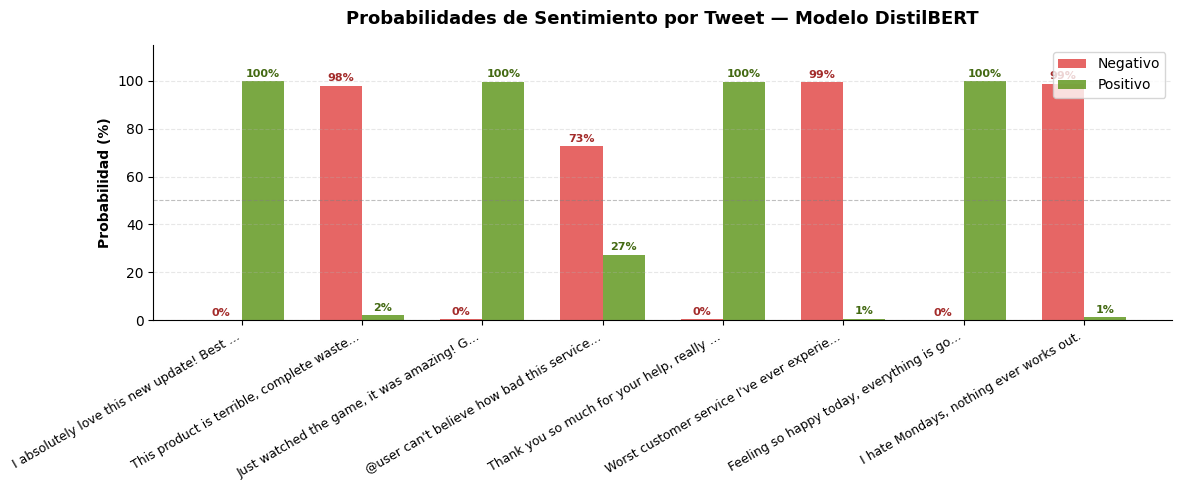

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# --- 15.1 Configuración del lienzo ---
fig, ax = plt.subplots(figsize=(12, 5))

n = len(results)
x = np.arange(n)
width = 0.35

# Extraer probabilidades quitando el símbolo '%' para poder graficarlas como números
neg_probs = [float(r['prob_negativo'].replace('%', '')) for r in results]
pos_probs = [float(r['prob_positivo'].replace('%', '')) for r in results]

# Dibujar las barras
ax.bar(x - width/2, neg_probs, width, label='Negativo', color='#E24B4A', alpha=0.85) # Rojo
ax.bar(x + width/2, pos_probs, width, label='Positivo', color='#639922', alpha=0.85) # Verde

# Recortar textos largos
short_labels = [r['texto_original'][:40] + '...' if len(r['texto_original']) > 40 else r['texto_original'] for r in results]

# Ajustes estéticos
ax.set_xticks(x)
ax.set_xticklabels(short_labels, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Probabilidad (%)', fontweight='bold')
ax.set_title('Probabilidades de Sentimiento por Tweet — Modelo DistilBERT', fontweight='bold', fontsize=13, pad=15)
ax.legend(loc='upper right')
ax.set_ylim(0, 115)

# Ocultar bordes innecesarios
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Línea del 50% que marca la frontera de decisión
ax.axhline(y=50, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

# Añadir los porcentajes encima de cada barra para máxima claridad visual
for i in range(n):
    ax.text(x[i] - width/2, neg_probs[i] + 1, f"{neg_probs[i]:.0f}%", ha='center', va='bottom', fontsize=8, color='#A32B2A', fontweight='bold')
    ax.text(x[i] + width/2, pos_probs[i] + 1, f"{pos_probs[i]:.0f}%", ha='center', va='bottom', fontsize=8, color='#436912', fontweight='bold')

plt.tight_layout()
# Guardamos el archivo
plt.savefig('realtime_predictions_distilbert.png', dpi=150, bbox_inches='tight')
plt.show()

# **12. GUARDAR EL MODEL**

In [29]:
import os

# --- 16.1 Definir el nombre de la carpeta de destino ---
output_dir = './modelo_distilbert_sentiment'

print(f"Guardando el modelo y el tokenizer en '{output_dir}'...")

# 1. Guardar el modelo Transformer con todos sus pesos entrenados
trainer.save_model(output_dir)

# 2. Guardar el tokenizer asociado para no perder el mapa de vocabulario
tokenizer.save_pretrained(output_dir)

print("==================================================")
print(" ¡PROCESO COMPLETADO! ")
print("==================================================")
print(f"Los archivos se guardaron correctamente en la carpeta: {output_dir}")
print("==================================================")

Guardando el modelo y el tokenizer en './modelo_distilbert_sentiment'...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

 ¡PROCESO COMPLETADO! 
Los archivos se guardaron correctamente en la carpeta: ./modelo_distilbert_sentiment
